# Activity 1.5 - Geyser dataset

**Seminario de Ciencia de Datos - Eliezer Lagunes Portela**

The `geyser` dataset records eruptions of the Old Faithful geyser in Yellowstone National Park:
`duration` (minutes of the eruption) and `waiting` (minutes until the next one).

Tools used: heat maps, correlation matrix, bag plot and DD plot.
The file `module.py` (Tukey depth) must be in the same folder as this notebook.
Insights are given as comments at the end.

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import module as mod

geyser = sns.load_dataset("geyser")
geyser.info() #Check the data types of the columns

<class 'pandas.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duration  272 non-null    float64
 1   waiting   272 non-null    int64  
 2   kind      272 non-null    str    
dtypes: float64(1), int64(1), str(1)
memory usage: 6.5 KB


In [2]:
#Numerical variables and basic description
num = geyser[["duration", "waiting"]]
print("Observations by kind")
print(geyser["kind"].value_counts())
num.describe()

Observations by kind
kind
long     172
short    100
Name: count, dtype: int64


,duration,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


          duration  waiting
duration    1.0000   0.9008
waiting     0.9008   1.0000


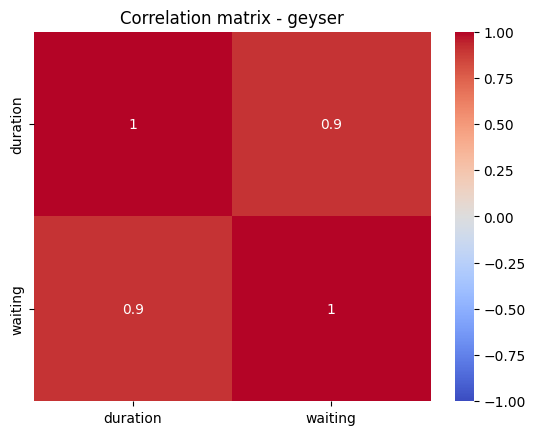

In [3]:
#Correlation matrix and its heat map
correlacion = num.corr()
print(correlacion.round(4))

sns.heatmap(correlacion, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix - geyser")
plt.show()

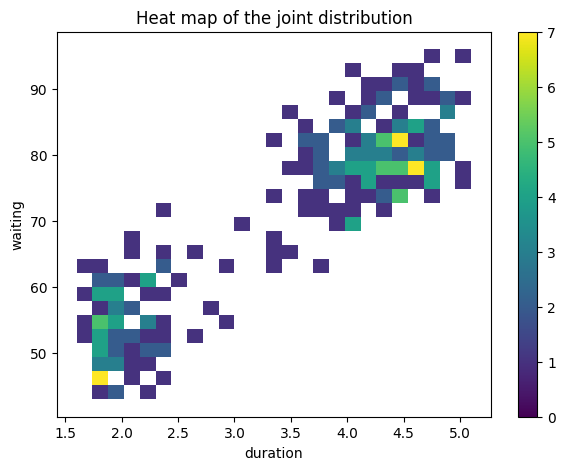

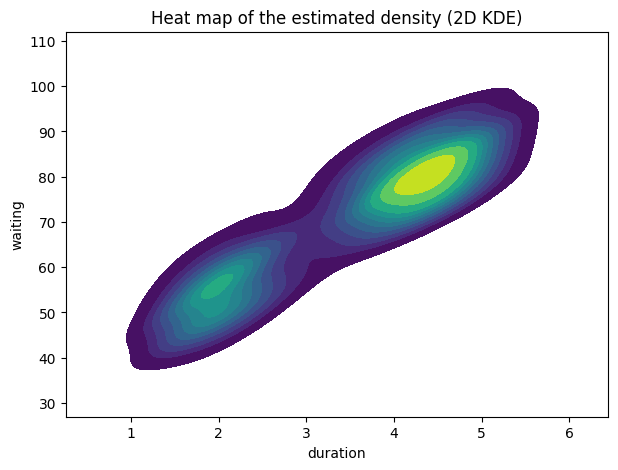

In [4]:
#Heat map of the joint density, to see where the observations really are
plt.figure(figsize=(7, 5))
sns.histplot(data=geyser, x="duration", y="waiting", bins=25, cbar=True, cmap="viridis")
plt.title("Heat map of the joint distribution")
plt.show()

plt.figure(figsize=(7, 5))
sns.kdeplot(data=geyser, x="duration", y="waiting", fill=True, cmap="viridis", levels=12)
plt.title("Heat map of the estimated density (2D KDE)")
plt.show()

Global correlation 0.9008
Correlation inside long 0.3227 n = 172
Correlation inside short 0.4278 n = 100


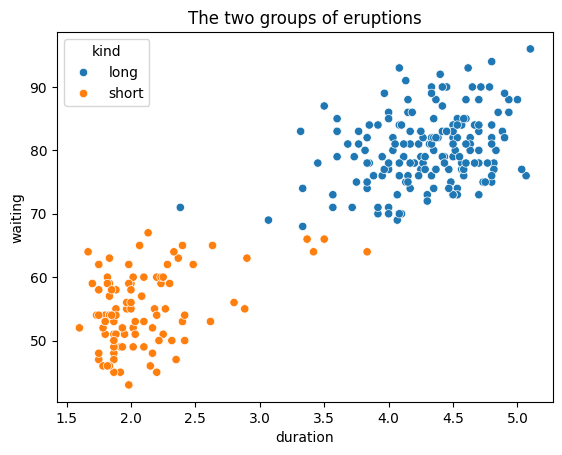

In [5]:
#The global correlation hides the group structure. Compute it inside each kind
print("Global correlation", round(num["duration"].corr(num["waiting"]), 4))
for k, g in geyser.groupby("kind"):
    print("Correlation inside", k, round(g["duration"].corr(g["waiting"]), 4), "n =", len(g))

sns.scatterplot(data=geyser, x="duration", y="waiting", hue="kind")
plt.title("The two groups of eruptions")
plt.show()

In [6]:
#Depth measures. Mahalanobis depth and Tukey (halfspace) depth
X = np.array(num)
mu = X.mean(axis=0)
S_inv = np.linalg.inv(np.cov(X, rowvar=False))

DM = np.sqrt(np.sum((X - mu) @ S_inv * (X - mu), axis=1))
M_Depth = 1 / (1 + DM**2)
Tukey_Depth = mod.tukey_depth(X)

print("Tukey depth   max", round(Tukey_Depth.max(), 4), " min", round(Tukey_Depth.min(), 4))
print("Mahalanobis depth   max", round(M_Depth.max(), 4), " min", round(M_Depth.min(), 4))

mediana_tukey = X[np.argmax(Tukey_Depth)]
print("Tukey median", mediana_tukey)
print("Deepest point for Mahalanobis", X[np.argmax(M_Depth)])

Tukey depth   max 0.4779  min 0.0
Mahalanobis depth   max 0.9796  min 0.1196
Tukey median [ 3.95 76.  ]
Deepest point for Mahalanobis [ 3.567 71.   ]


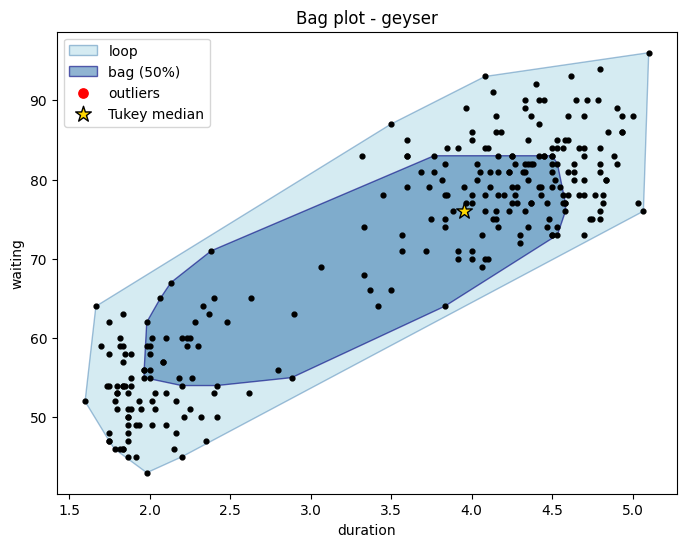

Observations inside the bag 136
Outliers detected by the bag plot 0
Composition of the bag by kind
kind
long     99
short    37
Name: count, dtype: int64


In [7]:
#Bag plot. The bag is the convex hull of the 50 percent deepest observations,
#the fence is the bag inflated three times around the Tukey median and the points
#outside the fence are the outliers
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon

def envolvente(P):
    return P[ConvexHull(P).vertices]

bolsa_puntos = X[Tukey_Depth >= np.median(Tukey_Depth)]
bolsa = envolvente(bolsa_puntos)
centro = mediana_tukey
cerca = centro + 3 * (bolsa - centro)

def dentro(P, poligono):
    from matplotlib.path import Path
    return Path(poligono).contains_points(P)

en_cerca = dentro(X, cerca)
atipicos = ~en_cerca
lazo_puntos = X[en_cerca]
lazo = envolvente(lazo_puntos)

fig, ax = plt.subplots(figsize=(8, 6))
ax.add_patch(Polygon(lazo, facecolor="lightblue", edgecolor="steelblue", alpha=0.5, label="loop"))
ax.add_patch(Polygon(bolsa, facecolor="steelblue", edgecolor="navy", alpha=0.6, label="bag (50%)"))
ax.scatter(X[:, 0], X[:, 1], s=12, color="black", zorder=3)
ax.scatter(X[atipicos, 0], X[atipicos, 1], s=45, color="red", zorder=4, label="outliers")
ax.scatter(centro[0], centro[1], s=140, marker="*", color="gold", edgecolor="black", zorder=5, label="Tukey median")
ax.set_xlabel("duration")
ax.set_ylabel("waiting")
ax.set_title("Bag plot - geyser")
ax.legend()
plt.show()

print("Observations inside the bag", len(bolsa_puntos))
print("Outliers detected by the bag plot", int(atipicos.sum()))
print("Composition of the bag by kind")
print(geyser.loc[Tukey_Depth >= np.median(Tukey_Depth), "kind"].value_counts())

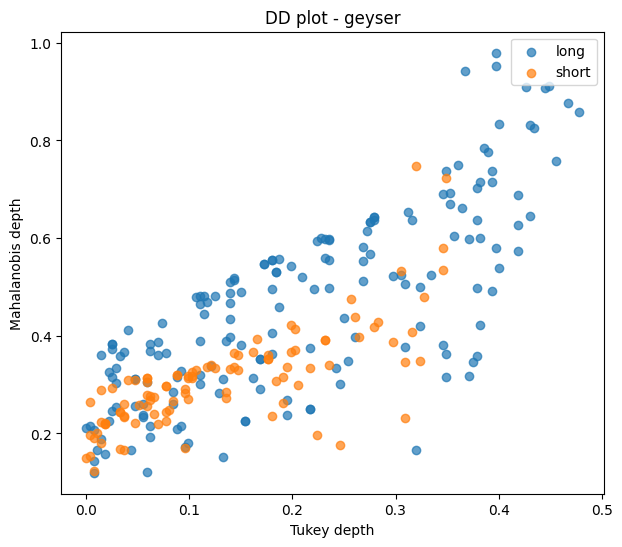

Pearson correlation between the two depths 0.779
Spearman correlation between the two depths 0.7603


In [8]:
#DD plot. Tukey depth against Mahalanobis depth
plt.figure(figsize=(7, 6))
for k in geyser["kind"].unique():
    m = (geyser["kind"] == k).values
    plt.scatter(Tukey_Depth[m], M_Depth[m], alpha=0.7, label=k)
plt.xlabel("Tukey depth")
plt.ylabel("Mahalanobis depth")
plt.title("DD plot - geyser")
plt.legend()
plt.show()

print("Pearson correlation between the two depths", round(np.corrcoef(Tukey_Depth, M_Depth)[0, 1], 4))
print("Spearman correlation between the two depths",
      round(pd.Series(Tukey_Depth).corr(pd.Series(M_Depth), method="spearman"), 4))

Flagged by Mahalanobis 7
Flagged by Tukey 11
Flagged by both 5


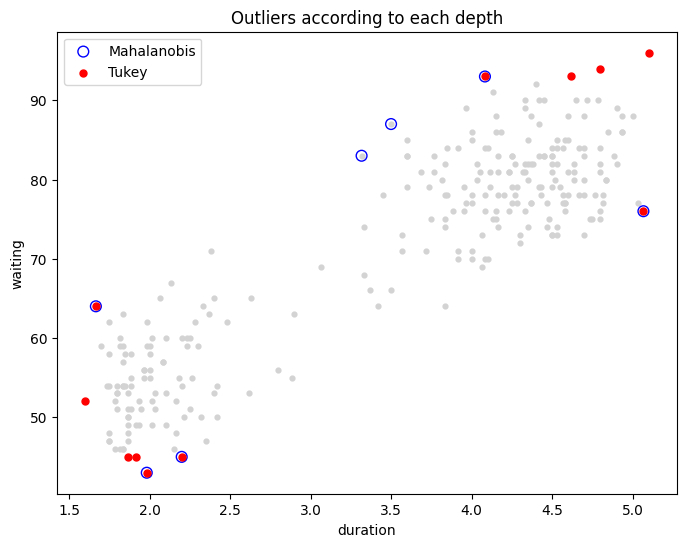

In [9]:
#Compare which observations each depth measure flags as outliers
atipicos_mahalanobis = M_Depth <= np.percentile(M_Depth, 2.5)
atipicos_tukey = Tukey_Depth <= np.percentile(Tukey_Depth, 2.5)

print("Flagged by Mahalanobis", int(atipicos_mahalanobis.sum()))
print("Flagged by Tukey", int(atipicos_tukey.sum()))
print("Flagged by both", int((atipicos_mahalanobis & atipicos_tukey).sum()))

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=12, color="lightgray")
plt.scatter(X[atipicos_mahalanobis, 0], X[atipicos_mahalanobis, 1], s=60,
            facecolor="none", edgecolor="blue", label="Mahalanobis")
plt.scatter(X[atipicos_tukey, 0], X[atipicos_tukey, 1], s=25, color="red", label="Tukey")
plt.xlabel("duration")
plt.ylabel("waiting")
plt.title("Outliers according to each depth")
plt.legend()
plt.show()

In [10]:
#INSIGHTS

#Insight 1. The correlation matrix says duration and waiting have a very strong linear
#relation, r = 0.9008. But that number is misleading. Inside the long eruptions the
#correlation is only 0.3227 and inside the short ones 0.4278. The 0.9 comes from having
#two separate groups, not from a strong relation inside them.

#Insight 2. Both heat maps show the two groups. The short eruptions are around
#duration = 1.98 minutes and waiting = 54 minutes, and the long ones around
#duration = 4.35 and waiting = 80. Between 2.5 and 3.3 minutes there are only 10 of the
#272 observations, so the groups are well separated. Short eruptions are followed by
#short waits and long ones by long waits.

#Insight 3. The bag plot does not work well here. The bag and the loop are convex, so
#they have to cover the empty space between the two groups. The bag ends up with 99 long
#eruptions and 37 short ones inside, so it is not describing one centre. The fence is the
#bag times three and it gets so wide that it finds zero outliers, even though the Tukey
#depth alone marks 11 points on the border. The Tukey median falls at (3.95, 76), inside
#the long group. Depth methods expect one centre and this data has two.

#Insight 4. The DD plot is not a straight line, it is a wide cloud. The correlation
#between the two depths is 0.779 with Pearson and 0.760 with Spearman. That means the
#data is not elliptical, which makes sense with two groups. The Mahalanobis depth only
#uses the global mean and the global covariance matrix, so it does not agree with the
#Tukey depth.

#Insight 5. The two depths do not mark the same points as outliers. At 2.5 percent
#Mahalanobis marks 7 points, Tukey marks 11, and only 5 are marked by both. Mahalanobis
#looks at how far a point is from the global centre. Tukey looks at how close a point is
#to the border in any direction. With two groups they stop agreeing.